# Roman Mission Plan — Exposure-Level Schedule

Build a joint exposure-level table by combining:
1. The segment-level schedule CSV (when each segment executes)
2. The APT simulator-input ECSV (what exposures comprise each segment)

See `Apr2026_MissionPlan/README.boxnote` for full methodology.

In [1]:
import os
import numpy as np
import pandas as pd
from astropy.table import Table
from astropy.time import Time
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


## Configuration

Change `APT_ECSV_FILENAME` to switch between programs (981=GPS, 994=HLWAS, 998=GBTDS, 999=HLTDS).

In [2]:
MISSION_PLAN_DIR   = "./Apr2026_MissionPlan"
APT_ECSV_FILENAME  = "APT_csv/999-hltds-Feb26.sim.ecsv"   # ← change to use a different program
SCHEDULE_FILENAME  = "schedule-RD26075MP1-run_id_RD26075MP1_R26069HJROLLP1.csv"

PID_MAP = {981: "GPS", 994: "HLWAS", 998: "GBTDS", 999: "HLTDS"}
apt_pid = int(APT_ECSV_FILENAME.split("/")[-1].split("-")[0])
print(f"Program: PID {apt_pid} ({PID_MAP.get(apt_pid, 'Unknown')})")

Program: PID 999 (HLTDS)


## Step 1 — Load the segment-level schedule CSV

In [3]:
schedule_df = pd.read_csv(os.path.join(MISSION_PLAN_DIR, SCHEDULE_FILENAME))
print(f"Total segments in schedule: {len(schedule_df)}")
schedule_df.head()

Total segments in schedule: 8527


,visit-id,duration,assigned orient,nominal orient,ra,dec,start,end,slew,gap
0,99401110003,8460.0,238.346555,229.747368,6.277555,-0.409579,2026.362:00:00:00,2026.362:02:21:38,NaN,NaN
1,99401110002,8460.0,238.346555,230.083962,6.274454,-0.450719,2026.362:02:27:32,2026.362:04:49:10,354.0,0.0
2,99401110001,8460.0,238.346555,230.528016,6.271035,-0.491781,2026.362:04:55:04,2026.362:07:16:43,354.0,0.0
3,99401125029,8784.0,224.163754,234.886134,0.178414,-0.703647,2026.362:07:22:37,2026.362:09:50:09,354.0,0.0
4,99401125027,8784.0,224.163754,236.088408,0.178822,-0.786049,2026.362:09:56:03,2026.362:12:23:36,354.0,0.0


Text(0.5, 1.0, 'Scheduled Pointings')

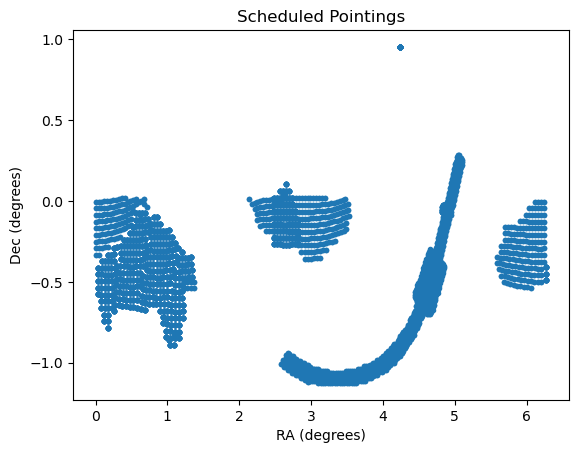

In [4]:
plt.scatter(schedule_df["ra"], schedule_df["dec"], marker=".")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.title("Scheduled Pointings")

## Step 2 — Parse `visit-id` into PLAN / PASS / SEGMENT

The `visit-id` column is actually a segment-id with format `PPPPPeepppsss`:
- `PPPPP` [0:5] — zero-padded program ID
- `ee` [5:7] — execution plan ID → matches `PLAN` in ECSV
- `ppp` [7:10] — pass ID → matches `PASS` in ECSV
- `sss` [10:13] — segment ID → matches `SEGMENT` in ECSV

In [5]:
vid = schedule_df['visit-id'].astype(str).str.zfill(13)
schedule_df['PID']     = vid.str[0:5].astype(int)
schedule_df['PLAN']    = vid.str[5:7].astype(int)
schedule_df['PASS']    = vid.str[7:10].astype(int)
schedule_df['SEGMENT'] = vid.str[10:13].astype(int)

# Filter to this program and rename ambiguous columns
schedule_pid = schedule_df[schedule_df['PID'] == apt_pid].copy()
schedule_pid = schedule_pid.rename(columns={
    'duration':        'segment_duration',
    'ra':              'segment_ra',
    'dec':             'segment_dec',
    'assigned orient': 'assigned_orient',
    'nominal orient':  'nominal_orient',
})
# Convert ra/dec from radians to degrees
schedule_pid['segment_ra'] = np.rad2deg(schedule_pid['segment_ra'])
schedule_pid['segment_dec'] = np.rad2deg(schedule_pid['segment_dec'])
print(f"Segments for PID {apt_pid} ({PID_MAP.get(apt_pid, 'Unknown')}): {len(schedule_pid)}")
schedule_pid.head()

Segments for PID 999 (HLTDS): 320


,visit-id,segment_duration,assigned_orient,nominal_orient,segment_ra,segment_dec,start,end,slew,gap,PID,PLAN,PASS,SEGMENT
407,99901001001,60876.0,NaN,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,1,1,1
591,99901009001,101628.0,NaN,333.450057,63.628375,-47.628611,2027.119:00:00:00,2027.120:04:19:40,1770.0,14872.0,999,1,9,1
600,99901002001,60876.0,NaN,20.251282,242.504167,54.510000,2027.125:07:16:43,2027.126:00:11:48,1770.0,14164.0,999,1,2,1
607,99901010001,101628.0,NaN,345.118342,63.628375,-47.628611,2027.130:04:13:46,2027.131:08:33:26,1770.0,29036.0,999,1,10,1
610,99901003001,60876.0,NaN,6.319965,242.504167,54.510000,2027.139:07:16:43,2027.140:00:11:48,2832.0,209272.0,999,1,3,1


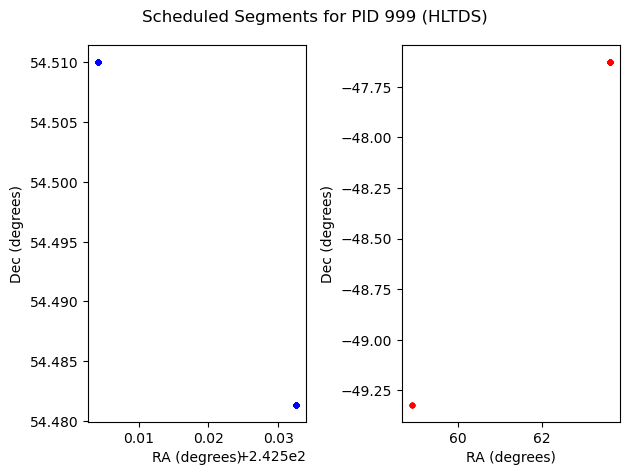

In [6]:
north = schedule_pid['segment_dec'] > 0
south = schedule_pid['segment_dec'] < 0
plt.subplot(1, 2, 1)
plt.scatter(schedule_pid[north]["segment_ra"], schedule_pid[north]["segment_dec"], marker=".", color="blue")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.subplot(1, 2, 2)
plt.scatter(schedule_pid[south]["segment_ra"], schedule_pid[south]["segment_dec"], marker=".", color="red")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.suptitle(f"Scheduled Segments for PID {apt_pid} ({PID_MAP.get(apt_pid, 'Unknown')})")
plt.tight_layout()

In [7]:
schedule_df[schedule_df['assigned orient'].isna()]['PID'].unique()
# HLTDS does not have assigned orientations

array([999, 981])

## Step 3 — Load the APT ECSV file

In [8]:
import re

apt_path = os.path.join(MISSION_PLAN_DIR, APT_ECSV_FILENAME)
with open(apt_path) as f:
    raw = f.read()

# TARGET_NAME can contain spaces (e.g. '<no name>'), which breaks the whitespace-delimited
# ECSV parser.  Replace spaces inside angle-bracket tokens before parsing.
raw_fixed = re.sub(r'<([^>]*)>', lambda m: '<' + m.group(1).replace(' ', '_') + '>', raw)

# astropy accepts the raw string content directly (not a file-like object)
apt_df = Table.read(raw_fixed, format="ascii.ecsv").to_pandas()
print(f"Exposures in ECSV: {len(apt_df)}")
apt_df.head()

Exposures in ECSV: 55216


,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME
0,242.897856,52.467151,0.0,F062,1001,122,1,1,1,1,1,1,60.08694,<no_name>
1,242.328393,52.667306,0.0,F062,1001,122,1,1,1,1,2,1,60.08694,<no_name>
2,241.753721,52.864789,0.0,F062,1001,122,1,1,1,1,3,1,60.08694,<no_name>
3,241.173859,53.059514,0.0,F062,1001,122,1,1,1,1,4,1,60.08694,<no_name>
4,240.588836,53.251394,0.0,F062,1001,122,1,1,1,1,5,1,60.08694,<no_name>


## Step 4 — Join schedule and ECSV on (PLAN, PASS, SEGMENT)

Each exposure row in the ECSV gets the schedule timing (`start`, `end`, `assigned_orient`) from its matching segment.

> **Note:** Use `assigned_orient` from the schedule for the position angle, not the `PA` column from the ECSV (which reflects the original tiling orientation and may differ).

In [9]:
keep_cols = schedule_pid.columns

joint_df = apt_df.merge(
    schedule_pid[keep_cols],
    on=['PLAN', 'PASS', 'SEGMENT'],
    how='inner',
)
print(f"Rows in joint table: {len(joint_df)}")
unmatched = joint_df['start'].isna().sum()
if unmatched:
    print(f"Warning: {unmatched} exposures with no matching schedule segment")
joint_df.head()

Rows in joint table: 55216


,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,...,segment_duration,assigned_orient,nominal_orient,segment_ra,segment_dec,start,end,slew,gap,PID
0,242.897856,52.467151,0.0,F062,1001,122,1,1,1,1,...,60876.0,NaN,31.054543,242.504167,54.51,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999
1,242.328393,52.667306,0.0,F062,1001,122,1,1,1,1,...,60876.0,NaN,31.054543,242.504167,54.51,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999
2,241.753721,52.864789,0.0,F062,1001,122,1,1,1,1,...,60876.0,NaN,31.054543,242.504167,54.51,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999
3,241.173859,53.059514,0.0,F062,1001,122,1,1,1,1,...,60876.0,NaN,31.054543,242.504167,54.51,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999
4,240.588836,53.251394,0.0,F062,1001,122,1,1,1,1,...,60876.0,NaN,31.054543,242.504167,54.51,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999


## Step 5 — Add derived columns

Parse schedule times to MJD and convert RA/DEC from radians to degrees.

In [10]:
def parse_schedule_time(time_str):
    """Convert YYYY.DOY:HH:MM:SS → MJD.  Astropy yday format uses YYYY:DOY:HH:MM:SS."""
    return Time(time_str.replace('.', ':', 1), format='yday').mjd

joint_df['mjd_start'] = joint_df['start'].apply(parse_schedule_time)
joint_df['mjd_end']   = joint_df['end'].apply(parse_schedule_time)

joint_df

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,...,nominal_orient,segment_ra,segment_dec,start,end,slew,gap,PID,mjd_start,mjd_end
0,242.897856,52.467151,0.0,F062,1001,122,1,1,1,1,...,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,61519.598356,61520.303275
1,242.328393,52.667306,0.0,F062,1001,122,1,1,1,1,...,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,61519.598356,61520.303275
2,241.753721,52.864789,0.0,F062,1001,122,1,1,1,1,...,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,61519.598356,61520.303275
3,241.173859,53.059514,0.0,F062,1001,122,1,1,1,1,...,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,61519.598356,61520.303275
4,240.588836,53.251394,0.0,F062,1001,122,1,1,1,1,...,31.054543,242.504167,54.510000,2027.114:14:21:38,2027.115:07:16:43,1770.0,6020.0,999,61519.598356,61520.303275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55211,60.415688,-48.923967,0.0,F087,1013,255,1,320,1,8,...,358.394228,63.628375,-47.628611,2030.143:00:00:00,2030.143:15:50:09,1416.0,4957.0,999,62644.000000,62644.659826
55212,59.884583,-48.729785,0.0,F087,1013,255,1,320,1,8,...,358.394228,63.628375,-47.628611,2030.143:00:00:00,2030.143:15:50:09,1416.0,4957.0,999,62644.000000,62644.659826
55213,59.357512,-48.533176,0.0,F087,1013,255,1,320,1,8,...,358.394228,63.628375,-47.628611,2030.143:00:00:00,2030.143:15:50:09,1416.0,4957.0,999,62644.000000,62644.659826
55214,58.834498,-48.334218,0.0,F087,1013,255,1,320,1,8,...,358.394228,63.628375,-47.628611,2030.143:00:00:00,2030.143:15:50:09,1416.0,4957.0,999,62644.000000,62644.659826


In [11]:
# save joint_df to ecsv 
joint_table = Table.from_pandas(joint_df)
joint_table.write(f"roman_opsim/joint_schedule_apt_pid{apt_pid}.ecsv", format="ascii.ecsv", overwrite=True)

## Plots

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_63816/3925834974.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


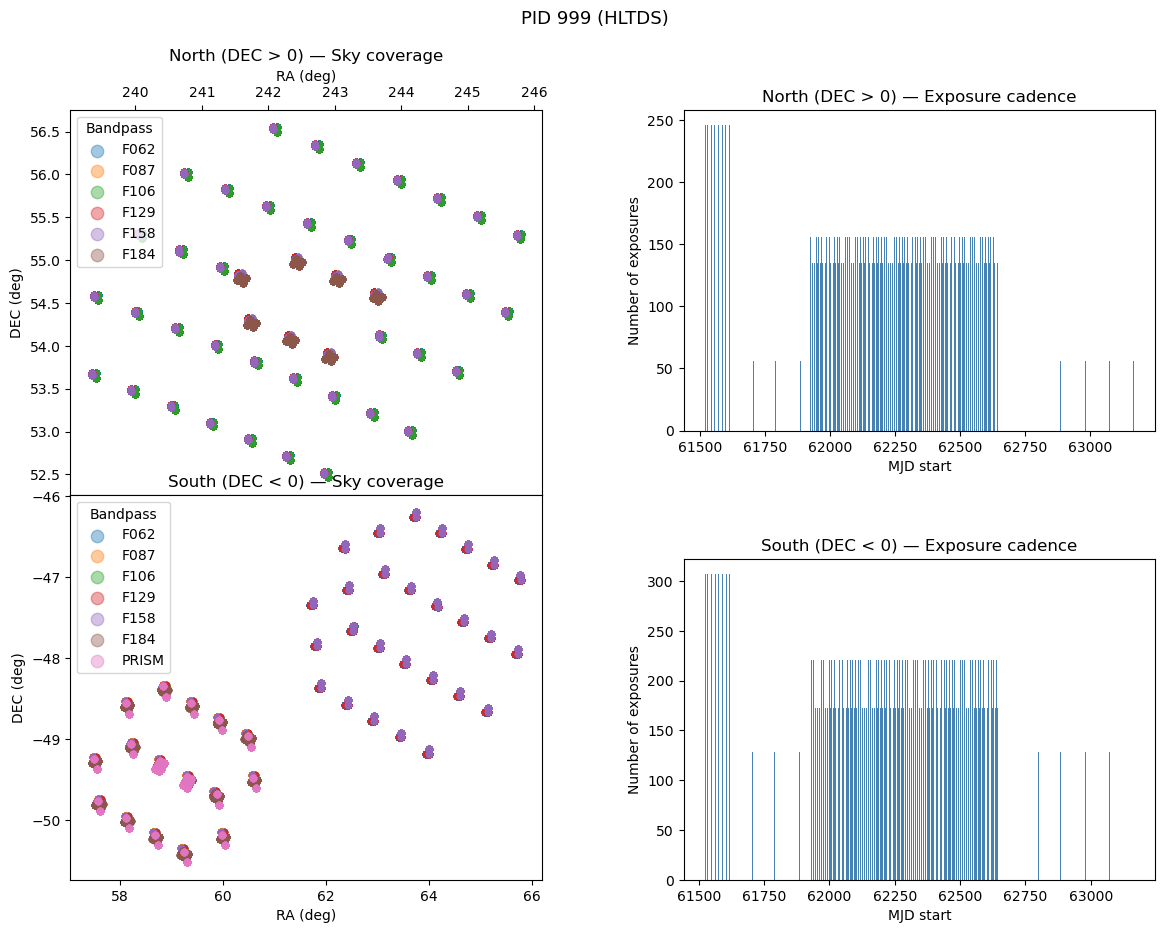

In [12]:

north = joint_df[joint_df['DEC'] > 0]
south = joint_df[joint_df['DEC'] < 0]

fig = plt.figure(figsize=(14, 10))
outer_gs = GridSpec(1, 2, figure=fig, wspace=0.3)

# Left column: sky coverage — north/south stacked with no gap, shared x-axis
inner_gs_sky = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0], hspace=0)
ax_sky_n = fig.add_subplot(inner_gs_sky[0])
ax_sky_s = fig.add_subplot(inner_gs_sky[1])

# Right column: cadence histograms — independent, normal spacing
inner_gs_cad = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1], hspace=0.4)
ax_cad_n = fig.add_subplot(inner_gs_cad[0])
ax_cad_s = fig.add_subplot(inner_gs_cad[1])

# North sky: x-axis ticks and label on top
ax_sky_n.xaxis.tick_top()
ax_sky_n.xaxis.set_label_position('top')
ax_sky_n.set_xlabel("RA (deg)")

for (label, df), ax_sky, ax_cad in zip(
    [("North (DEC > 0)", north), ("South (DEC < 0)", south)],
    [ax_sky_n, ax_sky_s],
    [ax_cad_n, ax_cad_s],
):
    # Sky coverage
    for bp, grp in df.groupby('BANDPASS'):
        ax_sky.scatter(grp['RA'], grp['DEC'], s=20, alpha=0.4, label=bp)
    ax_sky.set_ylabel("DEC (deg)")
    ax_sky.set_title(f"{label} — Sky coverage")
    ax_sky.legend(markerscale=2, title="Bandpass")

    # Temporal cadence
    ax_cad.hist(df['mjd_start'], bins=np.arange(df['mjd_start'].min(), df['mjd_start'].max() + 1,3), color='steelblue', edgecolor='none')
    ax_cad.set_xlabel("MJD start")
    ax_cad.set_ylabel("Number of exposures")
    ax_cad.set_title(f"{label} — Exposure cadence")

ax_sky_s.set_xlabel("RA (deg)")

plt.suptitle(f"PID {apt_pid} ({PID_MAP.get(apt_pid)})", fontsize=13)
plt.tight_layout()
plt.show()